# 01 — Data Acquisition

Downloads and caches all raw data sources for the HABRI project.  
No transformations beyond filtering to the North Carolina study area.

**Data sources:**
1. Census tract boundaries (pygris)
2. FEMA National Risk Index (manual CSV download)
3. HIFLD Cellular Towers (ArcGIS REST API)
4. Ookla Speedtest tiles (AWS S3 public bucket)
5. Census ACS 5-Year demographics (Census API)
6. OSMnx road network (Overpass API)

**Run this notebook first** — all subsequent notebooks depend on its outputs.

In [1]:
import sys
from pathlib import Path

# Ensure src/ is importable from notebooks/
sys.path.insert(0, str(Path("..").resolve()))

import geopandas as gpd
import pandas as pd
import numpy as np
import pygris
import matplotlib.pyplot as plt

from src.config import (
    STATE_FIPS, COUNTY_FIPS, COUNTY_FIPS_LIST, COUNTY_FIPS_FULL,
    CRS_PROJECT, CRS_WGS84,
    DATA_RAW, DATA_PROCESSED,
    NRI_TRACTFIPS_COL, NRI_STCOFIPS_COL, NRI_SCORE_COLS, NRI_RATING_COLS,
    HIFLD_TOWER_URL, HIFLD_MAX_RECORDS,
    OOKLA_QUARTERS, OOKLA_COLUMNS,
    ACS_VARIABLES, ACS_YEAR, CENSUS_API_KEY,
    ookla_s3_path,
)
from src.utils import (
    ensure_crs, get_study_area_bbox,
    query_arcgis_feature_layer, fetch_acs_state_tracts,
)

# Create output dirs if needed
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print(f"Study area: {len(COUNTY_FIPS)} NC counties")
print("Imports OK")

Study area: 100 NC counties
Imports OK


## A. Census Tract Boundaries

Download cartographic boundary tract shapefiles via `pygris` and reproject to EPSG:2264.

In [2]:
out_path = DATA_PROCESSED / "study_tracts.gpkg"

if out_path.exists():
    print(f"Loading cached tracts from {out_path}")
    tracts = gpd.read_file(out_path)
else:
    print(f"Downloading tract boundaries for all {len(COUNTY_FIPS)} NC counties...")
    tracts = pygris.tracts(
        state=STATE_FIPS,
        county=None,     # All counties in NC
        year=ACS_YEAR,   # 2022 — matches ACS vintage and 2020 Census tract defs
        cb=True,         # cartographic boundaries (clipped to shoreline)
    )
    tracts = tracts.to_crs(CRS_PROJECT)
    tracts.to_file(out_path, driver="GPKG")
    print(f"Saved {len(tracts)} tracts to {out_path}")

print(f"Tracts: {len(tracts)} | CRS: {tracts.crs} | Columns: {list(tracts.columns)}")
tracts.head()

Loading cached tracts from /Volumes/T9/Projects/HABRI/data/processed/study_tracts.gpkg


Tracts: 2660 | CRS: EPSG:2264 | Columns: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'AFFGEOID', 'GEOID', 'NAME', 'NAMELSAD', 'STUSPS', 'NAMELSADCO', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry']


,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,37,037,020600,1400000US37037020600,37037020600,206,Census Tract 206,NC,Chatham County,North Carolina,CT,303405835,2361346,"MULTIPOLYGON (((1880438.858 670581.594, 188070..."
1,37,105,030102,1400000US37105030102,37105030102,301.02,Census Tract 301.02,NC,Lee County,North Carolina,CT,15530241,303225,"MULTIPOLYGON (((1931321.752 621941.692, 193266..."
2,37,165,010300,1400000US37165010300,37165010300,103,Census Tract 103,NC,Scotland County,North Carolina,CT,24092918,308536,"MULTIPOLYGON (((1852915.797 362582.671, 185731..."
3,37,133,000800,1400000US37133000800,37133000800,8,Census Tract 8,NC,Onslow County,North Carolina,CT,1456231,47495,"MULTIPOLYGON (((2494562.242 362412.838, 249524..."
4,37,133,002500,1400000US37133002500,37133002500,25,Census Tract 25,NC,Onslow County,North Carolina,CT,21703677,11689,"MULTIPOLYGON (((2508374.515 358941.583, 251818..."


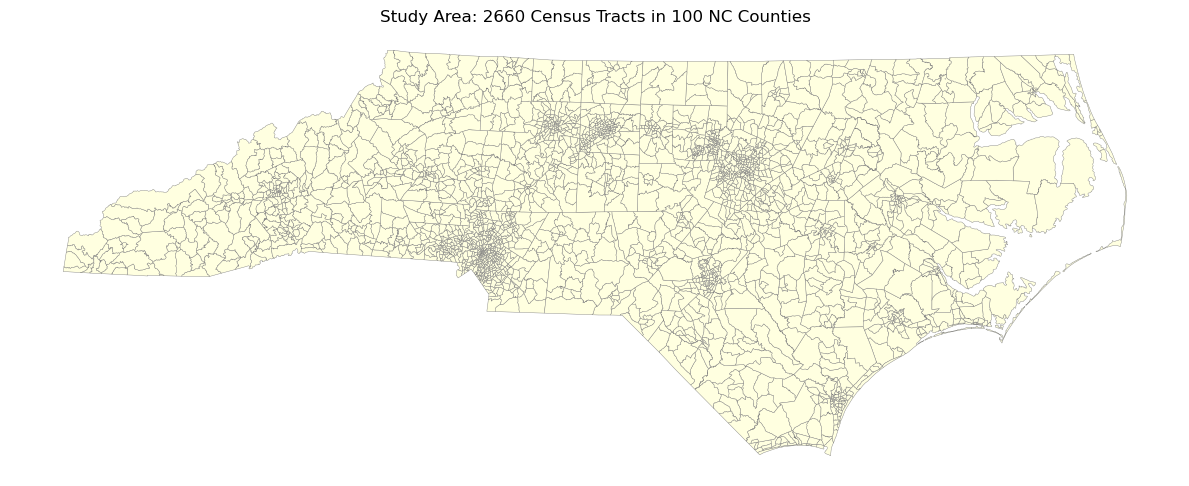

In [3]:
# Quick sanity plot
fig, ax = plt.subplots(figsize=(12, 10))
tracts.plot(ax=ax, edgecolor="gray", facecolor="lightyellow", linewidth=0.3)
ax.set_title(f"Study Area: {len(tracts)} Census Tracts in {len(COUNTY_FIPS)} NC Counties")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## B. FEMA National Risk Index (NRI)

The NRI tract-level CSV must be **downloaded manually** because FEMA has migrated
the data and old direct-download URLs now redirect.

**Steps:**
1. Go to https://hazards.fema.gov/nri/data-resources#csvDownload
2. Download the "Census Tracts" CSV (≈200–400 MB zipped)
3. Extract and place the CSV at: `data/raw/NRI_Table_CensusTracts.csv`

In [4]:
nri_raw_path = DATA_RAW / "NRI_Table_CensusTracts.csv"
nri_study_path = DATA_RAW / "nri_study_area.csv"

if nri_study_path.exists():
    print(f"Loading cached NRI study area data from {nri_study_path}")
    nri = pd.read_csv(nri_study_path, dtype={NRI_TRACTFIPS_COL: str, NRI_STCOFIPS_COL: str})

elif nri_raw_path.exists():
    print(f"Loading full NRI CSV from {nri_raw_path}...")
    nri_full = pd.read_csv(
        nri_raw_path,
        dtype={NRI_TRACTFIPS_COL: str, NRI_STCOFIPS_COL: str},
        low_memory=False,
    )
    print(f"Full NRI: {len(nri_full)} tracts nationwide")

    # Filter to study area counties
    nri = nri_full[nri_full[NRI_STCOFIPS_COL].isin(COUNTY_FIPS_FULL)].copy()
    print(f"Filtered to study area: {len(nri)} tracts")

    # Validate expected columns exist
    expected_cols = list(NRI_SCORE_COLS.keys()) + list(NRI_RATING_COLS.keys())
    missing = [c for c in expected_cols if c not in nri.columns]
    if missing:
        print(f"WARNING: Missing expected columns: {missing}")
    else:
        print("All expected hazard columns present.")

    nri.to_csv(nri_study_path, index=False)
    print(f"Saved study area NRI to {nri_study_path}")

else:
    print("=" * 70)
    print("FEMA NRI CSV not found!")
    print()
    print("Please download manually:")
    print("  1. Visit: https://hazards.fema.gov/nri/data-resources#csvDownload")
    print("  2. Download the 'Census Tracts' CSV")
    print(f"  3. Place it at: {nri_raw_path}")
    print("  4. Re-run this cell.")
    print("=" * 70)
    nri = None

Loading cached NRI study area data from /Volumes/T9/Projects/HABRI/data/raw/nri_study_area.csv


In [5]:
# Inspect NRI data
if nri is not None:
    score_cols = list(NRI_SCORE_COLS.keys())
    rating_cols = list(NRI_RATING_COLS.keys())

    print("Risk Scores (numeric):")
    display(nri[score_cols].describe())

    print("\nRisk Ratings (categorical):")
    for col in rating_cols:
        print(f"  {col}: {nri[col].value_counts().to_dict()}")

Risk Scores (numeric):


,IFLD_RISKS,HRCN_RISKS,LNDS_RISKS
count,2660.000000,2660.000000,2660.000000
mean,55.429122,71.299203,61.176989
std,25.307656,16.645439,20.158848
min,0.000000,9.271756,0.000000
25%,35.810650,56.677562,47.097559
50%,57.716457,68.899902,61.606198
75%,76.876197,84.989807,74.556443
max,99.680116,99.995782,99.975028



Risk Ratings (categorical):
  IFLD_RISKR: {'Relatively Moderate': 1037, 'Relatively Low': 828, 'Relatively High': 554, 'Very Low': 199, 'Very High': 41, 'No Rating': 1}
  HRCN_RISKR: {'Relatively Low': 1474, 'Relatively Moderate': 438, 'Very High': 298, 'Very Low': 260, 'Relatively High': 190}
  LNDS_RISKR: {'Very Low': 2221, 'Relatively Low': 252, 'Relatively Moderate': 134, 'Relatively High': 41, 'No Rating': 9, 'Very High': 3}


## C. HIFLD Cellular Towers

Query the ArcGIS REST FeatureServer for cellular towers in the study area.
Uses the paginated utility from `src/utils.py` to handle the 2000-record page limit.

In [6]:
tower_path = DATA_RAW / "hifld_cellular_towers.geojson"

if tower_path.exists():
    print(f"Loading cached towers from {tower_path}")
    towers = gpd.read_file(tower_path)
else:
    bbox = get_study_area_bbox(tracts, crs=CRS_WGS84)
    minx, miny, maxx, maxy = bbox
    print(f"Querying HIFLD towers within NC bbox: {bbox}")

    geometry_filter = {
        "geometryType": "esriGeometryEnvelope",
        "geometry": f"{minx},{miny},{maxx},{maxy}",
        "inSR": "4326",
        "spatialRel": "esriSpatialRelIntersects",
    }

    towers = query_arcgis_feature_layer(
        url=HIFLD_TOWER_URL,
        geometry_filter=geometry_filter,
        max_records=HIFLD_MAX_RECORDS,
    )

    towers.to_file(tower_path, driver="GeoJSON")
    print(f"Saved {len(towers)} towers to {tower_path}")

print(f"Towers: {len(towers)}")

Loading cached towers from /Volumes/T9/Projects/HABRI/data/raw/hifld_cellular_towers.geojson
Towers: 1275


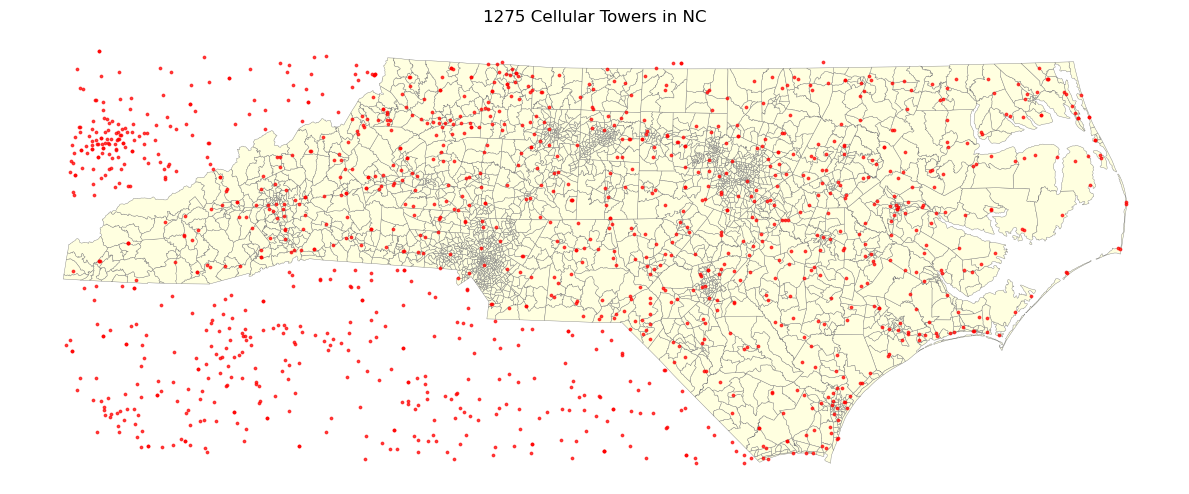

In [7]:
# Quick tower plot
fig, ax = plt.subplots(figsize=(12, 10))
tracts.plot(ax=ax, edgecolor="gray", facecolor="lightyellow", linewidth=0.3)
towers_proj = ensure_crs(towers)
towers_proj.plot(ax=ax, color="red", markersize=3, alpha=0.7)
ax.set_title(f"{len(towers)} Cellular Towers in NC")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## D. Ookla Speedtest Open Data

Read fixed-broadband performance tiles from the public AWS S3 bucket.  
We download **two quarters**: Q3 2024 (pre-Helene baseline) and Q4 2024 (during/post-Helene).

**Primary metric:** `avg_lat_ms` (latency as proxy for backhaul fragility).  
**Note:** Global parquet files are ~600 MB–1 GB each. This cell may take several minutes.

In [8]:
import s3fs
import pyarrow.parquet as pq

# Study area bounding box in WGS84 (Ookla tiles are in EPSG:4326)
bbox = get_study_area_bbox(tracts, crs=CRS_WGS84)
minx, miny, maxx, maxy = bbox
print(f"Study area bbox (WGS84): {bbox}")

fs = s3fs.S3FileSystem(anon=True)

for q_info in OOKLA_QUARTERS:
    year, quarter, label = q_info["year"], q_info["quarter"], q_info["label"]
    local_path = DATA_RAW / f"ookla_fixed_{label}.gpkg"

    if local_path.exists():
        print(f"[{label}] Cached at {local_path}")
        continue

    s3_path = ookla_s3_path(year, quarter)
    print(f"[{label}] Reading {s3_path} ...")

    try:
        # Read with pyarrow to avoid pandas 2.3 + pyarrow 16 compat issues
        table = pq.read_table(
            fs.open(s3_path),
            columns=OOKLA_COLUMNS,
        )
        print(f"  Global tiles: {table.num_rows:,}")

        # Convert column-by-column (avoids ndim error)
        data = {col: table.column(col).to_pylist() for col in OOKLA_COLUMNS}
        del table
        df = pd.DataFrame(data)
        for col in ["avg_d_kbps", "avg_u_kbps", "avg_lat_ms", "avg_lat_down_ms",
                     "avg_lat_up_ms", "tests", "devices"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")
        df["tile_x"] = pd.to_numeric(df["tile_x"], errors="coerce")
        df["tile_y"] = pd.to_numeric(df["tile_y"], errors="coerce")

        # Filter to study area bounding box using tile centroid coordinates
        mask = (
            (df["tile_x"] >= minx) & (df["tile_x"] <= maxx) &
            (df["tile_y"] >= miny) & (df["tile_y"] <= maxy)
        )
        df_local = df[mask].copy()
        del df
        print(f"  Filtered to study area: {len(df_local):,} tiles")

        # Create GeoDataFrame with point geometry from tile centroids
        geometry = gpd.points_from_xy(df_local["tile_x"], df_local["tile_y"])
        gdf = gpd.GeoDataFrame(df_local, geometry=geometry, crs=CRS_WGS84)

        gdf.to_file(local_path, driver="GPKG")
        print(f"  Saved to {local_path}")

    except Exception as e:
        print(f"  ERROR downloading {label}: {e}")
        print(f"  The S3 path may not exist yet. Check Ookla data availability.")

Study area bbox (WGS84): (np.float64(-84.32186900027445), np.float64(33.8423129108178), np.float64(-75.46061983488653), np.float64(36.588117047347176))
[pre_helene] Cached at /Volumes/T9/Projects/HABRI/data/raw/ookla_fixed_pre_helene.gpkg
[post_helene] Cached at /Volumes/T9/Projects/HABRI/data/raw/ookla_fixed_post_helene.gpkg


In [9]:
# Inspect pre-Helene Ookla data
ookla_pre_path = DATA_RAW / "ookla_fixed_pre_helene.gpkg"
if ookla_pre_path.exists():
    ookla_pre = gpd.read_file(ookla_pre_path)
    print(f"Pre-Helene (Q3 2024): {len(ookla_pre)} tiles")
    print(f"  avg_lat_ms range: {ookla_pre['avg_lat_ms'].min():.1f} – {ookla_pre['avg_lat_ms'].max():.1f}")
    print(f"  avg_lat_ms median: {ookla_pre['avg_lat_ms'].median():.1f}")
    display(ookla_pre.describe())
else:
    print("Pre-Helene Ookla data not yet downloaded.")

Pre-Helene (Q3 2024): 123435 tiles
  avg_lat_ms range: 0.0 – 2854.0
  avg_lat_ms median: 19.0


,tile_x,tile_y,avg_d_kbps,avg_u_kbps,avg_lat_ms,avg_lat_down_ms,avg_lat_up_ms,tests,devices
count,123435.000000,123435.000000,1.234350e+05,1.234350e+05,123435.000000,122504.000000,122563.000000,123435.000000,123435.000000
mean,-81.030183,35.270424,2.654992e+05,1.001332e+05,28.626889,367.208230,345.365012,8.384737,2.558910
std,2.137112,0.751649,1.809111e+05,1.418516e+05,68.954213,563.777108,654.677573,16.645145,2.711197
min,-84.317300,33.845300,2.000000e+00,1.000000e+00,0.000000,1.000000,2.000000,1.000000,1.000000
25%,-82.861600,34.721300,1.108170e+05,1.193800e+04,11.000000,110.000000,50.000000,1.000000,1.000000
50%,-81.010400,35.346500,2.574980e+05,2.631000e+04,19.000000,202.000000,114.000000,3.000000,2.000000
75%,-79.203200,35.900200,3.740390e+05,1.508315e+05,26.000000,398.000000,312.000000,9.000000,3.000000
max,-75.462300,36.586900,1.569598e+06,8.621805e+06,2854.000000,9981.000000,9940.000000,945.000000,62.000000


## E. Census ACS 5-Year Estimates

Fetch tract-level demographic variables from the Census API using a single state-level call.

**Variables:**
- No vehicle available (B08141_002E)
- Mobile-only internet (B28011_008E)
- Disability by age (C18108_006E, C18108_010E)
- Median household income (B19013_001E)
- Below poverty level (B17001_002E)
- Total population (B01003_001E)

In [10]:
acs_path = DATA_PROCESSED / "acs_demographics.csv"

if acs_path.exists():
    print(f"Loading cached ACS data from {acs_path}")
    acs = pd.read_csv(acs_path, dtype={"GEOID": str})
else:
    print(f"Fetching ACS {ACS_YEAR} 5-year data for all NC tracts (single state-level call)...")
    variable_codes = list(ACS_VARIABLES.keys())

    acs = fetch_acs_state_tracts(
        variables=variable_codes,
        state_fips=STATE_FIPS,
        year=ACS_YEAR,
        api_key=CENSUS_API_KEY,
    )
    print(f"  Retrieved {len(acs)} tracts statewide")

    # Filter to study area counties
    acs = acs[acs["GEOID"].str[:5].isin(COUNTY_FIPS_FULL)].copy()
    print(f"  After county filter: {len(acs)} tracts")

    # Rename variable codes to human-readable names
    acs = acs.rename(columns=ACS_VARIABLES)

    acs.to_csv(acs_path, index=False)
    print(f"Saved {len(acs)} tracts to {acs_path}")

print(f"ACS data: {len(acs)} tracts, {len(acs.columns)} columns")
acs.head()

Loading cached ACS data from /Volumes/T9/Projects/HABRI/data/processed/acs_demographics.csv
ACS data: 2672 tracts, 14 columns


,NAME,total_population,total_workers,total_hh_internet,no_vehicle,mobile_only_internet,disability_18_64,disability_65plus,median_household_income,below_poverty_level,state,county,tract,GEOID
0,Census Tract 201; Alamance County; North Carolina,4477.0,1924.0,1997.0,44.0,218.0,2788.0,759.0,51713.0,1410.0,37,1,20100,37001020100
1,Census Tract 202; Alamance County; North Carolina,4213.0,1636.0,1508.0,18.0,199.0,2628.0,562.0,33674.0,1434.0,37,1,20200,37001020200
2,Census Tract 203.01; Alamance County; North Ca...,4004.0,1499.0,1481.0,5.0,310.0,2021.0,633.0,35651.0,1157.0,37,1,20301,37001020301
3,Census Tract 203.02; Alamance County; North Ca...,3432.0,1448.0,1186.0,18.0,134.0,1757.0,527.0,51136.0,450.0,37,1,20302,37001020302
4,Census Tract 204; Alamance County; North Carolina,6682.0,2607.0,2630.0,16.0,422.0,3842.0,735.0,36136.0,1589.0,37,1,20400,37001020400


In [11]:
# Check for missing data
print("Missing values per column:")
print(acs[list(ACS_VARIABLES.values())].isnull().sum())

Missing values per column:
total_population            0
total_workers               0
total_hh_internet           0
no_vehicle                  0
mobile_only_internet        0
disability_18_64            0
disability_65plus           0
median_household_income    48
below_poverty_level         0
dtype: int64


## F. OSMnx Road Network

Download the driveable road network for the entire NC study area from OpenStreetMap.  
The graph is stored as GraphML for fast reload.

**Note:** The statewide road network is large (~860K nodes, ~2M edges).  
The initial download may take 15-30 minutes depending on Overpass API load.

In [12]:
import osmnx as ox

graph_path = DATA_RAW / "nc_road_network.graphml"

if graph_path.exists():
    print(f"Loading cached road network from {graph_path}")
    G = ox.load_graphml(str(graph_path))
else:
    print("Downloading statewide NC road network (this may take 15-30 minutes)...")

    # Dissolve all tracts into a single polygon for the query
    study_boundary = tracts.to_crs(CRS_WGS84).union_all()

    # Increase timeout for statewide query
    ox.settings.timeout = 600  # 10 minutes
    # Use absolute path for cache to avoid CWD issues on external volumes
    ox.settings.cache_folder = str(DATA_RAW / ".osmnx_cache")

    try:
        G = ox.graph_from_polygon(
            study_boundary,
            network_type="drive",
            simplify=True,
        )
    except Exception as e:
        print(f"Polygon query failed ({e}), falling back to place query...")
        G = ox.graph_from_place(
            "North Carolina, USA",
            network_type="drive",
            simplify=True,
        )

    ox.save_graphml(G, filepath=str(graph_path))
    print(f"Saved to {graph_path}")

print(f"Road network: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

/opt/anaconda3/lib/python3.12/site-packages/osmnx/_overpass.py:271: UserWarning: This area is 69 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


Saved to /Volumes/T9/Projects/HABRI/data/raw/nc_road_network.graphml


Road network: 648,424 nodes, 1,528,603 edges


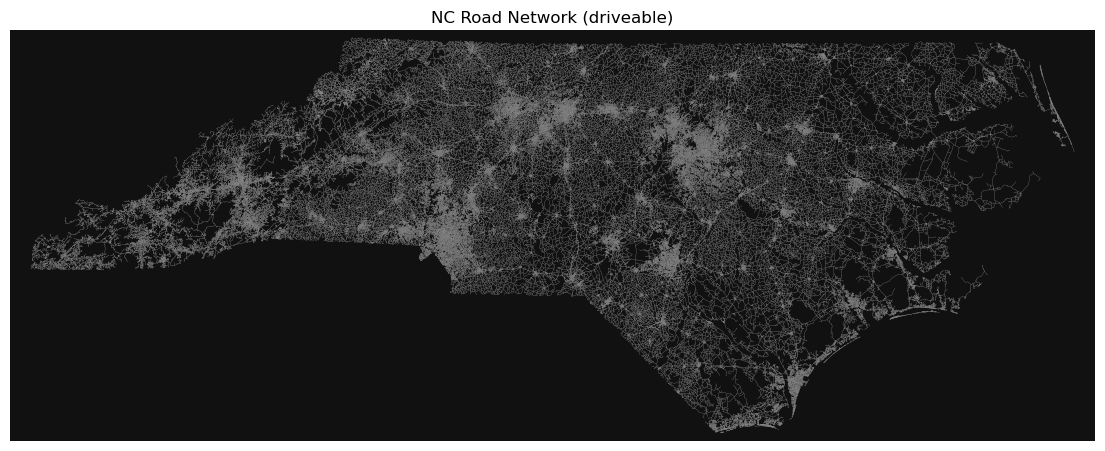

In [13]:
# Quick visualization of the road network
fig, ax = ox.plot_graph(G, figsize=(14, 10), node_size=0, edge_linewidth=0.1, show=False)
ax.set_title("NC Road Network (driveable)")
plt.show()

## G. IODA Outage Time-Series (WNC Case Study)

Fetch Internet Outage Detection and Analysis (IODA) time-series data from Georgia Tech
for Western NC ISPs impacted by Hurricane Helene. This provides BGP prefix visibility
and active probing data for validation.

In [ ]:
from src.config import WNC_ASNS, HELENE_START, HELENE_END
from src.utils import fetch_ioda_timeseries
from datetime import datetime

ioda_path = DATA_RAW / "ioda_asn_timeseries.csv"

if ioda_path.exists():
    print(f"Loading cached IODA data from {ioda_path}")
    ioda = pd.read_csv(ioda_path)
else:
    # Fetch 2 weeks before through end of Helene recovery
    start_ts = int(datetime(2024, 9, 15).timestamp())
    end_ts = int(datetime.strptime(HELENE_END, '%Y-%m-%d').timestamp())

    all_data = []
    for provider, asn in WNC_ASNS.items():
        for ds in ["bgp", "ping-slash24"]:
            print(f"Fetching {provider} (AS{asn}) {ds}...")
            df = fetch_ioda_timeseries(
                entity_type="asn",
                entity_code=str(asn),
                start_unix=start_ts,
                end_unix=end_ts,
                datasource=ds,
            )
            if df is not None and len(df) > 0:
                df["provider"] = provider
                df["asn"] = asn
                all_data.append(df)
                print(f"  Got {len(df)} rows")

    if all_data:
        ioda = pd.concat(all_data, ignore_index=True)
        ioda.to_csv(ioda_path, index=False)
        print(f"Saved {len(ioda)} rows to {ioda_path}")
    else:
        ioda = None
        print("WARNING: No IODA data retrieved.")

if ioda is not None:
    print(f"IODA data: {len(ioda)} rows, {ioda['provider'].nunique()} providers")


## Summary

Review what was downloaded and verify all expected files exist.

In [14]:
expected_files = {
    "Census tracts": DATA_PROCESSED / "study_tracts.gpkg",
    "NRI study area": DATA_RAW / "nri_study_area.csv",
    "HIFLD towers": DATA_RAW / "hifld_cellular_towers.geojson",
    "Ookla pre-Helene": DATA_RAW / "ookla_fixed_pre_helene.gpkg",
    "Ookla post-Helene": DATA_RAW / "ookla_fixed_post_helene.gpkg",
    "ACS demographics": DATA_PROCESSED / "acs_demographics.csv",
    "Road network": DATA_RAW / "nc_road_network.graphml",
    "IODA timeseries": DATA_RAW / "ioda_asn_timeseries.csv",
}

print("Data Acquisition Status:")
print("=" * 50)
all_present = True
for name, path in expected_files.items():
    exists = path.exists()
    size = f"{path.stat().st_size / 1024 / 1024:.1f} MB" if exists else "MISSING"
    status = "OK" if exists else "MISSING"
    print(f"  [{status:7s}] {name:20s} {size}")
    if not exists:
        all_present = False

print("=" * 50)
if all_present:
    print("All data sources acquired. Proceed to Notebook 02.")
else:
    print("Some data sources are missing. Review cells above for download instructions.")

Data Acquisition Status:
  [OK     ] Census tracts        4.7 MB
  [OK     ] NRI study area       15.0 MB
  [OK     ] HIFLD towers         1.1 MB
  [OK     ] Ookla pre-Helene     18.2 MB
  [OK     ] Ookla post-Helene    18.8 MB
  [OK     ] ACS demographics     0.3 MB
  [OK     ] Road network         866.5 MB
All data sources acquired. Proceed to Notebook 02.
